# MTC2026 - Venue Comparison Analysis
## Majestic Theater vs. Magic Stick

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel("../data/processed/master_show_data.xlsx", sheet_name="All Shows")
maj = pd.read_excel("../data/processed/master_show_data.xlsx", sheet_name="Majestic Theatre")
ms = pd.read_excel("../data/processed/master_show_data.xlsx", sheet_name="Magic Stick")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
maj['Date'] = pd.to_datetime(maj['Date'], errors='coerce')
ms['Date'] = pd.to_datetime(ms['Date'], errors='coerce')
print("Total shows:", len(df))
df.head()

df[df['Date'].isna()][['Venue', 'Event/Artist Name', 'Source Year (file)', 'Source File']]

Total shows: 845


,Venue,Event/Artist Name,Source Year (file),Source File
843,Majestic Theatre,Thursday,2024,2024_Majestic_Theater_Show_Results.xlsx
844,Magic Stick,Devault - Alley Deck,2024,2024_Show_Results_-_Magic_Stick.xlsx


## Data Cleaning & Engineering

In [92]:
# Fix Magic Stick capacities to 775
df.loc[df['Venue'] == 'Magic Stick', 'Venue Capacity'] = 775
df.loc[df['Venue'] == 'Magic Stick', 'Capacity Rate'] = df['Tickets Sold'] / 775

# Fix multi-night show
df.loc[df['Event/Artist Name'] == 'Between the Buried and Me-2 nights', 'Venue Capacity'] = 1550
df.loc[df['Event/Artist Name'] == 'Between the Buried and Me-2 nights', 'Capacity Rate'] = 1500 / 1550

# Flag rental events
df['is_rental'] = df['Promoter Name'] == 'Rental event'

# Flag Movement Festival weekend
df['is_movement'] = (df['Date'].dt.month == 5) & (df['Date'].dt.day >= 23) & (df['Date'].dt.day <= 27)

# Pre-COVID vs Post-COVID era flag
df['era'] = df['Date'].dt.year.apply(lambda x: 'Pre-COVID (2019)' if x == 2019 else 'Post-COVID (2022+)')

# Cost-adjusted net proceeds for Magic Stick (28% bar cost estimate)
ms = df[df['Venue'] == 'Magic Stick'].copy()
ms['bar_cogs_estimate'] = ms['Bar Revenue'] * 0.28
ms['estimated_net_proceeds'] = ms['Show Gross Proceeds'] - ms['bar_cogs_estimate']

print("Cleaning complete")
print("Rental events:", df['is_rental'].sum())
print("Movement weekend shows:", df['is_movement'].sum())

Cleaning complete
Rental events: 15
Movement weekend shows: 27


## 1. Venue Overview

In [93]:
df.groupby('Venue')[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue', 'Avg Alcohol $/Guest', 'Band(s) Guarantee']].mean().round(2)

,Capacity Rate,Gross Ticket Revenue,Bar Revenue,Avg Alcohol $/Guest,Band(s) Guarantee
Venue,,,,,
Magic Stick,0.54,13030.60,8439.56,20.69,7699.47
Majestic Theatre,0.67,28203.56,8382.78,21.61,14238.98


## 2. Year-over-Year Breakdown

In [94]:
df.groupby(['Venue', 'Source Year (file)'])[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue']].mean().round(2)

Capacity Rate  Gross Ticket Revenue  \
Venue            Source Year (file)                                        
Magic Stick      2019                         0.62              12582.05   
                 2022                         0.60              13858.20   
                 2023                         0.44              10010.27   
                 2024                         0.51              12596.92   
                 2025                         0.50              13251.68   
                 2026                         0.69              19445.98   
Majestic Theatre 2019                         0.61              19844.03   
                 2022                         0.70              26376.69   
                 2023                         0.78              32329.46   
                 2024                         0.60              28053.53   
                 2025                         0.62              31201.21   
                 2026                         0.82              38470.17   

                                     Bar Revenue  
Venue            Source Year (file)               
Magic Stick      2019                    8581.84  
                 2022                    9264.16  
                 2023                    7064.61  
                 2024                    8432.61  
                 2025                    8139.12  
                 2026                   10578.17  
Majestic Theatre 2019                    5650.73  
                 2022                    9283.68  
                 2023                    9785.55  
                 2024                    8591.71  
                 2025                    7624.65  
                 2026                   11281.75

## 3. Pre-COVID vs Post-COVID

In [95]:
df.groupby(['Venue', 'era'])[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue', 'Avg Alcohol $/Guest']].mean().round(2)

Capacity Rate  Gross Ticket Revenue  \
Venue            era                                                       
Magic Stick      Post-COVID (2022+)           0.52              13110.94   
                 Pre-COVID (2019)             0.62              12582.05   
Majestic Theatre Post-COVID (2022+)           0.69              30022.85   
                 Pre-COVID (2019)             0.61              19844.03   

                                     Bar Revenue  Avg Alcohol $/Guest  
Venue            era                                                   
Magic Stick      Post-COVID (2022+)      8413.17                21.39  
                 Pre-COVID (2019)        8581.84                16.79  
Majestic Theatre Post-COVID (2022+)      9007.47                24.27  
                 Pre-COVID (2019)        5650.73                 9.42

## 4. Gate vs Bar Revenue Breakdown

In [96]:
print("MAJESTIC (after AEG split):")
print("Avg Gate:", maj['Gate Settlement Gain/(Loss)'].mean().round(2))
print("Avg Bar (70% share):", maj['Majestic Share - Bar Sales (70%)'].mean().round(2))

print("\nMAGIC STICK (100% kept):")
print("Avg Gate:", ms['Gate Settlement Gain/(Loss)'].mean().round(2))
print("Avg Bar (100%):", ms['Bar Revenue'].mean().round(2))

MAJESTIC (after AEG split):
Avg Gate: 4156.05
Avg Bar (70% share): 5867.95

MAGIC STICK (100% kept):
Avg Gate: 1061.21
Avg Bar (100%): 8439.56


## 5. Profit Comparison (AEG Split Adjusted)

In [97]:
print("--- Per Show Average ---")
print("Majestic (after AEG split):", maj['Majestic Share - Show Gross Proceeds'].mean().round(2))
print("Magic Stick (gross):", ms['Show Gross Proceeds'].mean().round(2))
print("Magic Stick (est. after 35% bar cost):", ms['estimated_net_proceeds'].mean().round(2))

print("\n--- Totals ---")
print("Majestic total:", maj['Majestic Share - Show Gross Proceeds'].sum().round(2))
print("Magic Stick gross total:", ms['Show Gross Proceeds'].sum().round(2))
print("Magic Stick est. net total:", ms['estimated_net_proceeds'].sum().round(2))

--- Per Show Average ---
Majestic (after AEG split): 5754.82
Magic Stick (gross): 9283.06
Magic Stick (est. after 35% bar cost): 7091.98

--- Totals ---
Majestic total: 2566647.58
Magic Stick gross total: 3703941.42
Magic Stick est. net total: 2765873.22


## 6. Loss-Making Shows

In [98]:
loss = df[df['Gate Settlement Gain/(Loss)'] < 0]
print("Loss-making shows by venue:")
print(loss.groupby('Venue').size())
print("\nAs % of total shows:")
print((loss.groupby('Venue').size() / df.groupby('Venue').size() * 100).round(1))

print("\nAverage gate loss and bar offset:")
loss.groupby('Venue')[['Gate Settlement Gain/(Loss)', 'Bar Revenue']].mean().round(2)

Loss-making shows by venue:
Venue
Magic Stick         211
Majestic Theatre    159
dtype: int64

As % of total shows:
Venue
Magic Stick        52.90
Majestic Theatre   35.70
dtype: float64

Average gate loss and bar offset:


,Gate Settlement Gain/(Loss),Bar Revenue
Venue,,
Magic Stick,-2414.44,5454.53
Majestic Theatre,-4915.89,5641.61


## 7. Pricing Strategy — Ticket Price vs Capacity Rate

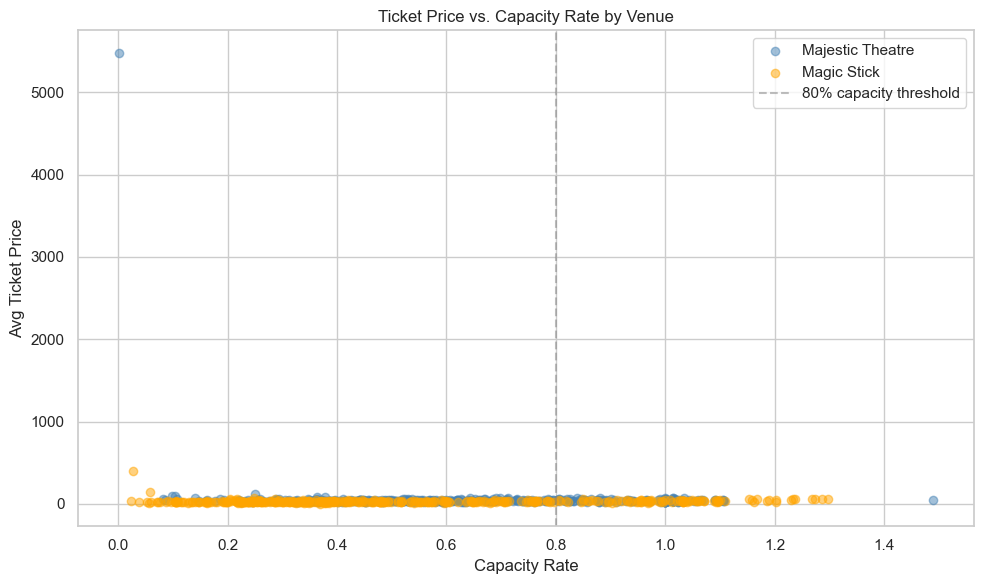

In [99]:
plt.figure(figsize=(10, 6))
for venue, color in [('Majestic Theatre', 'steelblue'), ('Magic Stick', 'orange')]:
    subset = df[df['Venue'] == venue]
    plt.scatter(subset['Capacity Rate'], subset['Avg Ticket Price (incl. TW rebate)'], 
                alpha=0.5, label=venue, color=color)
plt.xlabel('Capacity Rate')
plt.ylabel('Avg Ticket Price')
plt.axvline(0.8, color='gray', linestyle='--', alpha=0.5, label='80% capacity threshold')
plt.legend()
plt.title('Ticket Price vs. Capacity Rate by Venue')
plt.tight_layout()
plt.show()

## 8. Movement Festival Weekend

In [100]:
# Memorial Day weekend = Friday through Monday of last Monday in May
def is_movement_weekend(date):
    if pd.isna(date) or date.month != 5:
        return False
    # find the last Monday in May for that year
    import calendar
    year = date.year
    # get all days in May
    last_monday = max(
        day for day in range(1, 32)
        if calendar.monthrange(year, 5)[1] >= day
        and pd.Timestamp(year, 5, day).dayofweek == 0  # Monday
    )
    # weekend = Friday before through Monday
    memorial_day = pd.Timestamp(year, 5, last_monday)
    friday_before = memorial_day - pd.Timedelta(days=3)
    return friday_before <= date <= memorial_day

df['is_movement'] = df['Date'].apply(is_movement_weekend)
print("Movement weekend shows:", df['is_movement'].sum())
df[df['is_movement']][['Venue', 'Date', 'Event/Artist Name', 'Promoter Name']].sort_values('Date')

Movement weekend shows: 26


,Venue,Date,Event/Artist Name,Promoter Name
54,Majestic Theatre,2019-05-24,Architects,NaN
55,Magic Stick,2019-05-24,Walker And Royce,Paxahau - Tom Pattyn
56,Majestic Theatre,2019-05-25,Local Natives,NaN
57,Magic Stick,2019-05-25,Detroit Love,Paxahau - Tom Pattyn
58,Majestic Theatre,2019-05-26,Basement,NaN
59,Magic Stick,2019-05-26,Origins,Paxahau - Tom Pattyn
60,Majestic Theatre,2019-05-27,Chromatics,NaN
61,Magic Stick,2019-05-27,Repopulate Mars,Paxahau - Tom Pattyn
213,Magic Stick,2022-05-27,Dsert Hearts,NaN
214,Magic Stick,2022-05-28,Claude Von Stroke,NaN


In [101]:
df.groupby('is_movement')[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue', 'Avg Alcohol $/Guest']].mean().round(2)

,Capacity Rate,Gross Ticket Revenue,Bar Revenue,Avg Alcohol $/Guest
is_movement,,,,
False,0.60,20539.07,8154.31,21.25
True,1.01,36764.43,16352.02,18.88


## 9. Promoter Comparison (Magic Stick)

In [102]:
promoters = ['In-House - Zach', 'In-House - Brie', 'Paxahau - Tom Pattyn', 'In-house - Tom']
ms[ms['Promoter Name'].isin(promoters)].groupby('Promoter Name')[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue', 'Gate Settlement Gain/(Loss)', 'Show Gross Proceeds']].mean().round(2)

,Capacity Rate,Gross Ticket Revenue,Bar Revenue,Gate Settlement Gain/(Loss),Show Gross Proceeds
Promoter Name,,,,,
In-House - Brie,0.27,5651.15,5203.26,-2199.75,2896.24
In-House - Zach,0.44,10682.93,4605.95,330.23,4921.01
In-house - Tom,0.50,10805.06,9625.33,954.51,10579.85
Paxahau - Tom Pattyn,0.66,17101.60,13122.81,2221.67,14748.14


## 10. Day of Week Patterns

In [103]:
df['Day of Week'] = df['Date'].dt.strftime('%a')
df['Day of Week'].value_counts()
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print("Average metrics by day:")
print(df.groupby('Day of Week')[['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue']].mean().reindex(dow_order).round(2))

print("\nShow count by day and venue:")
df.groupby(['Day of Week', 'Venue']).size().unstack().reindex(dow_order)

Average metrics by day:
             Capacity Rate  Gross Ticket Revenue  Bar Revenue
Day of Week                                                  
Mon                   0.64              25766.98      7303.00
Tue                   0.68              27209.55      8170.03
Wed                   0.60              24005.95      6778.10
Thu                   0.54              19440.19      7638.63
Fri                   0.61              19051.29      9391.09
Sat                   0.60              18799.12      9251.21
Sun                   0.67              25277.00      6677.74

Show count by day and venue:


Venue,Magic Stick,Majestic Theatre
Day of Week,,
Mon,15,23
Tue,12,48
Wed,25,63
Thu,33,73
Fri,142,83
Sat,138,105
Sun,33,50


## 11. Seasonal Patterns

In [104]:
df.groupby(['Venue', df['Date'].dt.month])[['Capacity Rate', 'Gross Ticket Revenue']].mean().round(2)

Capacity Rate  Gross Ticket Revenue
Venue            Date                                      
Magic Stick      1.00            0.65              17609.56
                 2.00            0.66              14827.52
                 3.00            0.52              12276.56
                 4.00            0.52              10928.60
                 5.00            0.76              21945.90
                 6.00            0.36               7624.49
                 7.00            0.48              12185.62
                 8.00            0.34               8685.99
                 9.00            0.48              10479.26
                 10.00           0.48              10956.31
                 11.00           0.47              10713.29
                 12.00           0.58              13122.12
Majestic Theatre 1.00            0.76              28794.10
                 2.00            0.74              31062.23
                 3.00            0.71              26425.12
                 4.00            0.72              32216.76
                 5.00            0.68              27409.98
                 6.00            0.62              26186.41
                 7.00            0.64              25068.12
                 8.00            0.66              26385.11
                 9.00            0.63              26540.42
                 10.00           0.55              23663.59
                 11.00           0.66              28031.26
                 12.00           0.80              40584.71

## 12. Oversold Shows

In [105]:
oversold = df[df['Capacity Rate'] > 1.0]
print("Oversold shows by venue:")
print(oversold.groupby('Venue').size())
print("\nAvg revenue on oversold shows:")
oversold.groupby('Venue')[['Gross Ticket Revenue', 'Bar Revenue']].mean().round(2)

Oversold shows by venue:
Venue
Magic Stick         50
Majestic Theatre    56
dtype: int64

Avg revenue on oversold shows:


,Gross Ticket Revenue,Bar Revenue
Venue,,
Magic Stick,33192.73,20856.73
Majestic Theatre,48285.14,11149.78


## 13. Top & Bottom Shows

In [106]:
print("TOP 10 by Gross Ticket Revenue:")
display(df.nlargest(10, 'Gross Ticket Revenue')[['Venue', 'Date', 'Event/Artist Name', 'Tickets Sold', 'Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue']])

print("\nBOTTOM 10 by Gate Settlement:")
display(df.nsmallest(10, 'Gate Settlement Gain/(Loss)')[['Venue', 'Date', 'Event/Artist Name', 'Capacity Rate', 'Gate Settlement Gain/(Loss)', 'Bar Revenue']])

TOP 10 by Gross Ticket Revenue:


,Venue,Date,Event/Artist Name,Tickets Sold,Capacity Rate,Gross Ticket Revenue,Bar Revenue
820,Majestic Theatre,2026-04-28,They Might be Giants,1772.00,0.81,103352.68,17972.20
423,Majestic Theatre,2023-12-08,Dogstar,1115.00,1.01,82908.00,12640.77
644,Majestic Theatre,2025-04-06,Ninja Sex Party,1115.00,1.01,74947.92,7207.09
757,Majestic Theatre,2025-11-14,Minus the Bear,1138.00,1.03,74600.00,18218.52
373,Majestic Theatre,2023-08-27,JVKE,1100.00,1.00,69720.00,5914.50
346,Majestic Theatre,2023-06-21,Ruel,1101.00,1.00,69112.76,4152.72
647,Majestic Theatre,2025-04-11,G-Eazy,968.00,0.88,65887.97,19799.35
781,Majestic Theatre,2026-01-10,State Champs,1119.00,1.02,64930.16,19430.24
629,Majestic Theatre,2025-02-28,D'Yadrian Harding,922.00,0.84,63552.59,3469.90
773,Majestic Theatre,2025-12-10,Earl Sweatshirt,990.00,0.90,63204.99,8338.53



BOTTOM 10 by Gate Settlement:


,Venue,Date,Event/Artist Name,Capacity Rate,Gate Settlement Gain/(Loss),Bar Revenue
735,Majestic Theatre,2025-10-12,ALY & AJ,0.73,-19407.62,7678.42
645,Majestic Theatre,2025-04-09,Bayside 4.9 & 4.10 TWO NIGHTS,0.42,-18744.30,12751.25
726,Majestic Theatre,2025-10-04,The Rapture,0.16,-17865.11,3013.78
723,Majestic Theatre,2025-10-02,Noah Cyrus,0.47,-17083.55,6394.07
429,Majestic Theatre,2023-12-30,Black Xmas,0.93,-15629.38,26651.67
417,Majestic Theatre,2023-11-27,Deafhaven,0.46,-14597.85,5724.65
729,Majestic Theatre,2025-10-08,Evil Dead,0.29,-13777.60,3369.03
721,Majestic Theatre,2025-09-28,Gottmik,0.14,-12671.00,3318.12
738,Majestic Theatre,2025-10-16,Sons of the East,0.22,-12371.07,2523.23
698,Majestic Theatre,2025-07-26,Sleater-Kinney,0.53,-12328.79,6269.84


In [107]:
df['Day of Week'].value_counts()

Day of Week
Sat    243
Fri    225
Thu    106
Wed     88
Sun     83
Tue     60
Mon     38
Name: count, dtype: int64

## 13. Genre Analysis

In [108]:
# Genre Analysis
genre_cols = ['Capacity Rate', 'Gross Ticket Revenue', 'Bar Revenue', 
              'Avg Alcohol $/Guest', 'Gate Settlement Gain/(Loss)', 
              'Show Gross Proceeds', 'Band(s) Guarantee', 
              'Avg Ticket Price (incl. TW rebate)']

df.groupby('Genre')[genre_cols].mean().round(2).sort_values('Gross Ticket Revenue', ascending=False)

,Capacity Rate,Gross Ticket Revenue,Bar Revenue,Avg Alcohol $/Guest,Gate Settlement Gain/(Loss),Show Gross Proceeds,Band(s) Guarantee,Avg Ticket Price (incl. TW rebate)
Genre,,,,,,,,
Hip-Hop/R&B,0.67,27939.60,6413.61,12.38,6291.48,12533.40,12742.35,40.79
Pop,0.65,27437.14,5432.56,8.25,3499.55,8932.11,13646.92,38.58
Country/Americana,0.65,26517.75,11082.48,16.17,1550.21,12632.68,14069.57,38.48
Rock,0.65,25156.91,8117.32,12.45,3324.87,11434.62,13546.81,35.65
Metal/Hard Rock,0.62,22829.87,8304.18,15.47,1731.10,10035.28,13121.98,36.83
Jazz/Blues/Soul,0.55,20070.60,5792.77,12.02,4561.19,10353.96,8873.64,36.16
Comedy/Other,0.56,16644.41,4052.07,95.52,2357.70,6409.77,7881.03,158.25
Electronic/Dance,0.58,15970.73,10278.82,21.65,1632.59,11639.07,8992.07,30.86


In [109]:
# Genre by venue - see which genres each venue books more
df.groupby(['Genre', 'Venue']).size().unstack(fill_value=0)

Venue,Magic Stick,Majestic Theatre
Genre,,
Comedy/Other,10,41
Country/Americana,2,17
Electronic/Dance,271,72
Hip-Hop/R&B,23,51
Jazz/Blues/Soul,7,13
Metal/Hard Rock,26,47
Pop,10,54
Rock,50,151


In [110]:
# Loss-making shows by genre
loss = df[df['Gate Settlement Gain/(Loss)'] < 0]
loss_pct = (loss.groupby('Genre').size() / df.groupby('Genre').size() * 100).round(1)
print("% of shows losing money on gate by genre:")
print(loss_pct.sort_values(ascending=False))

% of shows losing money on gate by genre:
Genre
Electronic/Dance    51.90
Metal/Hard Rock     45.20
Jazz/Blues/Soul     45.00
Country/Americana   42.10
Rock                37.80
Pop                 37.50
Comedy/Other        35.30
Hip-Hop/R&B         32.40
dtype: float64


In [111]:
# Bar revenue offsets gate loss by genre
loss = loss.copy()
loss['net_after_bar'] = loss['Gate Settlement Gain/(Loss)'] + loss['Bar Revenue']
loss.groupby('Genre')[['Gate Settlement Gain/(Loss)', 'Bar Revenue', 'net_after_bar']].mean().round(2)

,Gate Settlement Gain/(Loss),Bar Revenue,net_after_bar
Genre,,,
Comedy/Other,-4053.76,4385.59,331.83
Country/Americana,-5501.74,8089.89,2588.15
Electronic/Dance,-2837.35,6529.26,3687.13
Hip-Hop/R&B,-3133.28,3491.72,358.44
Jazz/Blues/Soul,-1438.78,3669.78,2231.00
Metal/Hard Rock,-4674.32,5518.78,844.46
Pop,-5215.67,3393.99,-1821.68
Rock,-3966.67,4800.95,834.28


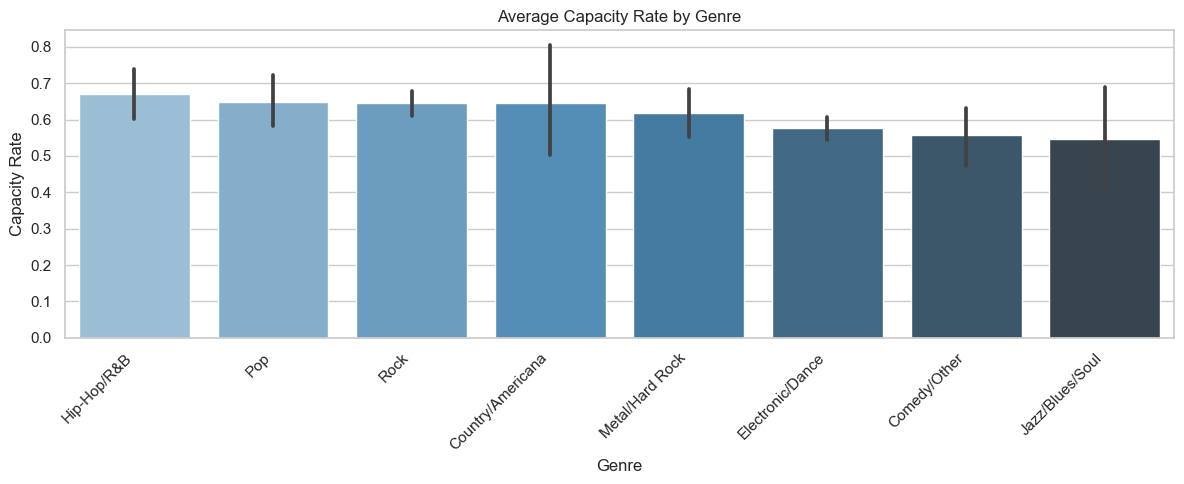

In [112]:
# Genre capacity rate chart
plt.figure(figsize=(12, 5))
genre_order = df.groupby('Genre')['Capacity Rate'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Genre', y='Capacity Rate', order=genre_order, palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Average Capacity Rate by Genre')
plt.tight_layout()
plt.show()

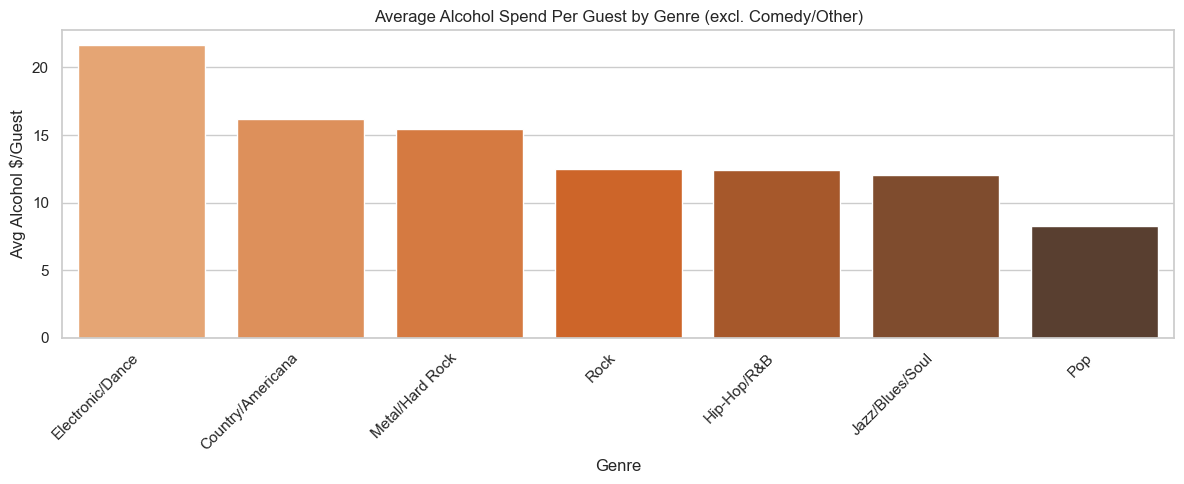

In [113]:
# Avg alcohol per guest by genre - your "drinking behavior" finding
genre_alc = df[df['Genre'] != 'Comedy/Other'].groupby('Genre')['Avg Alcohol $/Guest'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_alc.index, y=genre_alc.values, palette='Oranges_d')
plt.xticks(rotation=45, ha='right')
plt.title('Average Alcohol Spend Per Guest by Genre (excl. Comedy/Other)')
plt.xlabel('Genre')
plt.ylabel('Avg Alcohol $/Guest')
plt.tight_layout()
plt.show()

In [119]:
# Ad hoc analysis
print("Majestic Performance Pre Covid (2019) vs. Post Covid (2025)\n")
display(maj[maj['Source Year (file)'].isin([2019, 2025])].groupby('Source Year (file)')[['Tickets Sold', 'Gross Ticket Revenue', 'Bar Revenue']].mean().round(2))

print("Magic Stick Performance Pre Covid (2019) vs. Post Covid (2025)\n")
display(ms[ms['Source Year (file)'].isin([2019, 2025])].groupby('Source Year (file)')[['Tickets Sold', 'Gross Ticket Revenue', 'Bar Revenue']].mean().round(2))

Majestic Performance Pre Covid (2019) vs. Post Covid (2025)



,Tickets Sold,Gross Ticket Revenue,Bar Revenue
Source Year (file),,,
2019,608.33,19844.03,5650.73
2025,681.13,31201.21,7624.65


Magic Stick Performance Pre Covid (2019) vs. Post Covid (2025)



,Tickets Sold,Gross Ticket Revenue,Bar Revenue
Source Year (file),,,
2019,482.53,12582.05,8581.84
2025,383.87,13251.68,8139.12


In [124]:
# Artists who have played more than once
repeat = df.groupby('Event/Artist Name').agg(
    shows=('Date', 'count'),
    venues=('Venue', 'nunique'),
    avg_capacity_rate=('Capacity Rate', 'mean'),
    avg_tickets=('Tickets Sold', 'mean'),
    avg_gross_ticket=('Gross Ticket Revenue', 'mean'),
    avg_bar=('Bar Revenue', 'mean'),
    avg_proceeds=('Show Gross Proceeds', 'mean'),
    first_show=('Date', 'min'),
    last_show=('Date', 'max'),
).reset_index()

repeat = repeat[repeat['shows'] > 1].sort_values('shows', ascending=False)

print(f"Artists who have played more than once: {len(repeat)}")
display(repeat.head(20).round(2))

Artists who have played more than once: 69


,Event/Artist Name,shows,venues,avg_capacity_rate,avg_tickets,avg_gross_ticket,avg_bar,avg_proceeds,first_show,last_show
178,Desert Hearts,4,1,0.62,484.25,13230.00,12980.25,10874.16,2019-02-23,2025-04-26
535,Repopulate Mars,3,1,0.97,754.67,31478.27,14091.50,20423.14,2019-05-27,2026-05-25
12,Afrobeats to the World,3,1,0.75,583.00,16368.12,11072.00,15800.72,2025-04-12,2026-05-09
353,Kevin Saunderson,3,1,1.03,799.67,41122.33,22764.50,31193.58,2022-11-30,2026-05-24
90,Boombox,3,1,0.57,440.50,10517.65,8138.67,10420.01,2023-03-15,2025-02-15
122,Claude Von Stroke,3,1,1.07,829.67,35735.00,20973.26,30169.44,2022-05-28,2023-08-04
473,Nora En Pure,2,1,1.06,820.50,37469.00,21225.50,27145.43,2024-01-05,2026-03-28
488,Omnom,2,1,1.06,818.50,27064.28,20990.50,29341.72,2025-01-25,2026-02-28
483,Of Montreal,2,1,0.68,524.50,14716.00,5520.35,8072.20,2019-10-23,2024-06-08
482,Odd Mob,2,1,1.27,985.00,57369.00,23200.00,43734.00,2025-05-25,2026-05-23


In [122]:
from scipy import stats

# First time vs repeat artists
repeat_names = repeat[repeat['shows'] > 1]['Event/Artist Name'].tolist()

first_time = df[~df['Event/Artist Name'].isin(repeat_names)]['Capacity Rate'].dropna()
returning = df[df['Event/Artist Name'].isin(repeat_names)]['Capacity Rate'].dropna()

print(f"First-time artists: {len(first_time)} shows, avg cap rate: {first_time.mean():.3f}")
print(f"Repeat artists: {len(returning)} shows, avg cap rate: {returning.mean():.3f}")

t_stat, p_value = stats.ttest_ind(first_time, returning)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Statistically significant (p < 0.05): {p_value < 0.05}")

First-time artists: 691 shows, avg cap rate: 0.601
Repeat artists: 144 shows, avg cap rate: 0.653

t-statistic: -1.887
p-value: 0.0595
Statistically significant (p < 0.05): False


In [123]:
print("TOP 10 REPEAT ARTISTS:")
display(repeat.head(10)[['Event/Artist Name', 'shows', 'avg_capacity_rate', 'avg_gross_ticket', 'avg_bar']].round(2))

print("\nBOTTOM 10 REPEAT ARTISTS (by capacity rate):")
display(repeat[repeat['shows'] > 1].nsmallest(10, 'avg_capacity_rate')[['Event/Artist Name', 'shows', 'avg_capacity_rate', 'avg_gross_ticket', 'avg_bar']].round(2))

TOP 10 REPEAT ARTISTS:


,Event/Artist Name,shows,avg_capacity_rate,avg_gross_ticket,avg_bar
178,Desert Hearts,4,0.62,13230.00,12980.25
535,Repopulate Mars,3,0.97,31478.27,14091.50
12,Afrobeats to the World,3,0.75,16368.12,11072.00
353,Kevin Saunderson,3,1.03,41122.33,22764.50
90,Boombox,3,0.57,10517.65,8138.67
122,Claude Von Stroke,3,1.07,35735.00,20973.26
473,Nora En Pure,2,1.06,37469.00,21225.50
488,Omnom,2,1.06,27064.28,20990.50
483,Of Montreal,2,0.68,14716.00,5520.35
482,Odd Mob,2,1.27,57369.00,23200.00



BOTTOM 10 REPEAT ARTISTS (by capacity rate):


,Event/Artist Name,shows,avg_capacity_rate,avg_gross_ticket,avg_bar
534,Reality Gays,2,0.17,5685.75,1916.17
606,Spencer Brown,2,0.20,3152.88,3528.50
583,Simon Doty,2,0.22,3778.62,3552.00
264,Golden Features,2,0.23,4942.75,3128.92
384,Little Miss Nasty,2,0.25,7175.53,3139.50
75,Biscits,2,0.27,4289.25,6443.50
208,EDX,2,0.31,6726.50,9476.30
415,Marsh,2,0.35,6436.88,6504.00
445,Moon Boots,2,0.35,6239.50,6476.88
347,Kasbo,2,0.36,8487.33,5997.16


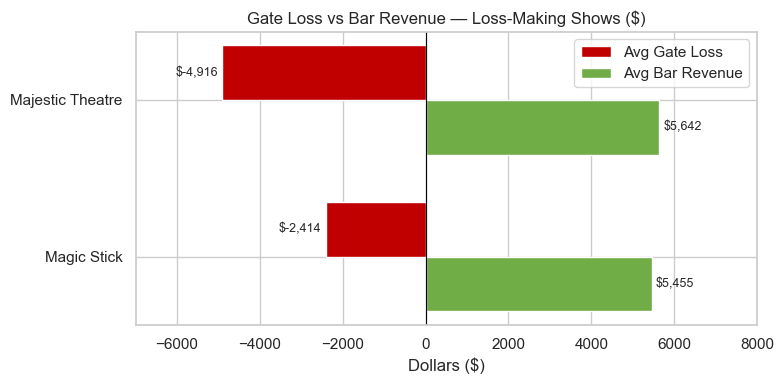

In [125]:
import matplotlib.pyplot as plt
import numpy as np

venues = ['Magic Stick', 'Majestic Theatre']
gate_losses = [-2414, -4916]
bar_revenues = [5455, 5642]

x = np.arange(len(venues))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.barh(x + width/2, gate_losses, width, label='Avg Gate Loss', color='#C00000')
bars2 = ax.barh(x - width/2, bar_revenues, width, label='Avg Bar Revenue', color='#70AD47')

ax.set_xlabel('Dollars ($)')
ax.set_title('Gate Loss vs Bar Revenue — Loss-Making Shows ($)')
ax.set_yticks(x)
ax.set_yticklabels(venues, fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.legend()
ax.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=9)
ax.set_xlim(-7000, 8000)

plt.tight_layout()
plt.savefig('../reports/gate_loss_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()